# Task 3: BART Cross-Dialect Evaluation
**PDEBench-Lang | Raghav Anand | CSCI 5541**

**What we are doing:**
1. Pretrain BART on a small mix of all 4 dialects (250 instances × 4 = 1000 examples)
2. Fine-tune 4 separate models from that checkpoint, one per dialect
3. Test each model on all 4 dialects → 4×4 results matrix

**Enable GPU first:** Runtime → Change runtime type → T4 GPU

In [7]:
!pip install -q "torch==2.1.0" "transformers[torch]" "accelerate>=1.1.0" rouge_score scikit-learn evaluate

ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch==2.1.0


In [8]:
!pip install -q evaluate rouge_score

In [9]:
# Step 1: Install packages
import sys
!{sys.executable} -m pip install -q "transformers[torch]" "accelerate>=1.1.0" rouge_score scikit-learn
!pip install -q evaluate rouge_score

In [10]:
# Step 2: Imports
import json, random, re, os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
import evaluate

# Fix random seeds so results are reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cuda


In [13]:
# Step 3: Upload dataset
from google.colab import files

DATASET_PATH = "/content/dataset (4).jsonl"
OUTPUT_ROOT  = '/content/bart_task3'
os.makedirs(OUTPUT_ROOT, exist_ok=True)

if not os.path.exists(DATASET_PATH):
    uploaded = files.upload()
    for fname in uploaded:
        os.rename(fname, DATASET_PATH)

# Load and check
with open(DATASET_PATH) as f:
    data = [json.loads(l) for l in f]

print(f'Loaded {len(data)} instances')
print('Families:', Counter(d['family'] for d in data))
print('\nSample input  :', data[0]['dialects']['natural'])
print('Sample target :', data[0]['target'])

Loaded 12000 instances
Families: Counter({'Burgers': 2000, 'KleinGordon': 2000, 'Wave': 2000, 'Laplace': 2000, 'Heat': 2000, 'Advection': 2000})

Sample input  : The time derivative of u plus u times its spatial derivative in z equals 1.26 times the second derivative in z.
Sample target : family: Burgers | operators: exp, polynomial | reasoning: ν=1.26 exceeds 0.6 in z; diffusion dominates and the solution decays smoothly — exponential basis functions apply.


In [14]:
# Step 4: Split into train / val / test
# 80% train, 10% val, 10% test
# Stratified means each family gets the same proportion in each split

labels = [d['family'] for d in data]
train_val, test_data = train_test_split(data,     test_size=0.1,     stratify=labels,                             random_state=SEED)
train_data, val_data = train_test_split(train_val, test_size=0.1/0.9, stratify=[d['family'] for d in train_val],  random_state=SEED)

print(f'train={len(train_data)} | val={len(val_data)} | test={len(test_data)}')

train=9600 | val=1200 | test=1200


In [15]:
# Step 5: Load BART tokenizer
# We add 4 special tokens so the model knows which dialect it is reading

DIALECTS  = ['natural', 'latex', 'prefix', 'postfix']
tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')
tokenizer.add_special_tokens({
    'additional_special_tokens': [f'[DIALECT_{d.upper()}]' for d in DIALECTS]
})
print('Tokenizer ready. Vocab size:', len(tokenizer))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer ready. Vocab size: 50269


In [16]:
# Step 6: Build training examples
# Each example = one dialect of one PDE instance
# Input:  [DIALECT_X] classify PDE family and infer structure: <equation>
# Target: family: X | operators: Y | reasoning: Z
#
# For pretrain: pass all 4 dialects  -> 1 instance becomes 4 examples
# For finetune: pass only 1 dialect  -> 1 instance becomes 1 example

def build_examples(instances, dialects):
    examples = []
    for inst in instances:
        for dialect in dialects:
            examples.append({
                'input' : f'[DIALECT_{dialect.upper()}] classify PDE family and infer structure: {inst["dialects"][dialect]}',
                'target': inst['target'],
            })
    return examples


# PyTorch Dataset class — tokenizes examples and returns tensors for the Trainer
class PDEDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples
        self.inputs  = tokenizer([e['input']  for e in examples], max_length=256, truncation=True, padding='max_length')
        self.targets = tokenizer([e['target'] for e in examples], max_length=128, truncation=True, padding='max_length')

    def __len__(self): return len(self.examples)

    def __getitem__(self, idx):
        # Replace padding id with -100 in labels so loss ignores padding
        labels = [t if t != tokenizer.pad_token_id else -100 for t in self.targets['input_ids'][idx]]
        return {
            'input_ids'     : torch.tensor(self.inputs['input_ids'][idx],      dtype=torch.long),
            'attention_mask': torch.tensor(self.inputs['attention_mask'][idx], dtype=torch.long),
            'labels'        : torch.tensor(labels,                             dtype=torch.long),
        }

print('build_examples and PDEDataset ready')

build_examples and PDEDataset ready


In [17]:
# Step 7: Training function
# Wraps the Seq2SeqTrainer so we can call it simply:
#   train_model(model, train_examples, val_examples, output_dir, epochs, lr)

def train_model(model, train_examples, val_examples, output_dir, epochs, lr):
    model.resize_token_embeddings(len(tokenizer))

    args = Seq2SeqTrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=lr,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        predict_with_generate=False,
        fp16=(device == 'cuda'),
        weight_decay=0.01,
        save_total_limit=1,
        report_to='none',
        seed=SEED,
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=PDEDataset(train_examples),
        eval_dataset =PDEDataset(val_examples),
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model, padding=True),
    )
    trainer.train()
    model.save_pretrained(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))
    return model

print('train_model ready')

train_model ready


In [18]:
# Step 8: Evaluation function
# Generates predictions for a list of examples and computes 3 metrics:
#   family_accuracy — did it predict the right PDE family?
#   operator_f1     — did it predict the right operators?
#   rougeL          — how close is the full generated string to the target?

rouge = evaluate.load('rouge')

def evaluate_model(model, examples):
    model.eval()
    model.to(device)
    preds, refs = [], []

    # Generate predictions in batches of 32
    for i in range(0, len(examples), 32):
        batch = examples[i:i+32]
        enc   = tokenizer([e['input'] for e in batch], max_length=256, truncation=True, padding=True, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model.generate(enc['input_ids'], attention_mask=enc['attention_mask'], max_new_tokens=128, num_beams=4)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend([e['target'] for e in batch])

    # Family accuracy: parse 'family: X' from predicted string
    def get_family(text):
        m = re.search(r'family:\s*([^|]+)', text)
        return m.group(1).strip().lower() if m else ''

    fam_acc = sum(get_family(p) == get_family(r) for p, r in zip(preds, refs)) / len(preds)

    # Operator F1: parse 'operators: X, Y' and compute micro F1
    def get_ops(text):
        m = re.search(r'operators:\s*([^|]+)', text)
        return set(o.strip().lower() for o in m.group(1).split(',')) if m else set()

    tp = fp = fn = 0
    for p, r in zip(preds, refs):
        pp, rr = get_ops(p), get_ops(r)
        tp += len(pp & rr); fp += len(pp - rr); fn += len(rr - pp)
    prec = tp/(tp+fp) if (tp+fp) else 0
    rec  = tp/(tp+fn) if (tp+fn) else 0
    op_f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0

    # ROUGE-L: full string similarity
    rougeL = rouge.compute(predictions=preds, references=refs, use_stemmer=True)['rougeL']

    return {'family_accuracy': fam_acc, 'operator_f1': op_f1, 'rougeL': rougeL}

print('evaluate_model ready')

evaluate_model ready


In [19]:
# ============================================================
# STAGE 1: Pretrain on small mixed dataset
# ============================================================
# Take 250 instances, expand to all 4 dialects = 1000 examples.
# Pretrain BART on this mixed set so it sees all dialects early.
# Save checkpoint — Stage 2 loads from here.

pretrain_dir = Path(OUTPUT_ROOT) / 'pretrained'
pretrain_dir.mkdir(parents=True, exist_ok=True)

# Sample 250 instances from train
rng = random.Random(SEED)
pool = list(train_data); rng.shuffle(pool)
pretrain_instances = pool[:250]
pretrain_val_instances = list(val_data)[:25]

pretrain_train_ex = build_examples(pretrain_instances,     DIALECTS)  # 1000 examples
pretrain_val_ex   = build_examples(pretrain_val_instances, DIALECTS)  # 100 examples

print(f'Pretrain train examples: {len(pretrain_train_ex)}')
print(f'Pretrain val   examples: {len(pretrain_val_ex)}')

pretrained_model = BartForConditionalGeneration.from_pretrained('facebook/bart-base')
pretrained_model = train_model(pretrained_model, pretrain_train_ex, pretrain_val_ex, pretrain_dir, epochs=3, lr=2e-4)

print('Stage 1 done!')

Pretrain train examples: 1000
Pretrain val   examples: 100


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 1 done!


In [20]:
# ============================================================
# STAGE 2: Fine-tune one model per dialect
# ============================================================
# Load Stage 1 checkpoint 4 times.
# Each time fine-tune on the full train set using only one dialect.
# Result: 4 models, each expert in one dialect.

finetune_models = {}

for dialect in DIALECTS:
    print(f'\nFine-tuning on dialect: {dialect}')
    dialect_dir = Path(OUTPUT_ROOT) / 'finetuned' / dialect
    dialect_dir.mkdir(parents=True, exist_ok=True)

    # Load from Stage 1 checkpoint
    model = BartForConditionalGeneration.from_pretrained(str(pretrain_dir))

    # Build single-dialect examples from full train set
    train_ex = build_examples(train_data, [dialect])  # ~9600 examples
    val_ex   = build_examples(val_data,   [dialect])  # ~1200 examples

    model = train_model(model, train_ex, val_ex, dialect_dir, epochs=3, lr=2e-4)
    finetune_models[dialect] = model
    print(f'Done: {dialect}')

print('\nStage 2 done! All 4 models trained.')


Fine-tuning on dialect: natural


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,0.104170,0.050455
2,0.050139,0.035932
3,0.037377,0.028882


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done: postfix

Stage 2 done! All 4 models trained.


In [21]:
# ============================================================
# STAGE 3: Cross-dialect evaluation
# ============================================================
# Test each of the 4 models on all 4 dialects.
# Produces a 4x4 matrix.
# Diagonal = model tested on its own dialect (expected high)
# Off-diagonal = model tested on a different dialect (the key result)

# Build test examples for each dialect once
test_by_dialect = {d: build_examples(test_data, [d]) for d in DIALECTS}

results = {}
for train_d in DIALECTS:
    results[train_d] = {}
    for eval_d in DIALECTS:
        print(f'train={train_d} | eval={eval_d}...', end=' ')
        m = evaluate_model(finetune_models[train_d], test_by_dialect[eval_d])
        results[train_d][eval_d] = m
        print(f'family_acc={m["family_accuracy"]:.2%} | op_f1={m["operator_f1"]:.2%} | rougeL={m["rougeL"]:.3f}')

# Print family accuracy matrix
print('\n=== Family Accuracy Matrix ===')
print(f'{"":>12}' + ''.join(f'{d:>10}' for d in DIALECTS))
for td in DIALECTS:
    print(f'{td:>12}' + ''.join(f'{results[td][ed]["family_accuracy"]:>10.2%}' for ed in DIALECTS))

train=natural | eval=natural... family_acc=100.00% | op_f1=98.49% | rougeL=0.667
train=natural | eval=latex... family_acc=38.67% | op_f1=79.40% | rougeL=0.444
train=natural | eval=prefix... family_acc=37.08% | op_f1=77.43% | rougeL=0.460
train=natural | eval=postfix... family_acc=33.08% | op_f1=79.64% | rougeL=0.441
train=latex | eval=natural... family_acc=34.83% | op_f1=76.29% | rougeL=0.455
train=latex | eval=latex... family_acc=100.00% | op_f1=98.84% | rougeL=0.675
train=latex | eval=prefix... family_acc=34.83% | op_f1=74.55% | rougeL=0.445
train=latex | eval=postfix... family_acc=44.25% | op_f1=79.63% | rougeL=0.478
train=prefix | eval=natural... family_acc=26.00% | op_f1=80.06% | rougeL=0.469
train=prefix | eval=latex... family_acc=36.75% | op_f1=82.86% | rougeL=0.480
train=prefix | eval=prefix... family_acc=99.83% | op_f1=98.23% | rougeL=0.670
train=prefix | eval=postfix... family_acc=44.83% | op_f1=83.46% | rougeL=0.500
train=postfix | eval=natural... family_acc=39.67% | op_f1=7

In [22]:
# Step 9: Save results and print full tables

out_path = Path(OUTPUT_ROOT) / 'task3_results.json'
out_path.write_text(json.dumps(results, indent=2))
print(f'Saved to {out_path}')

for metric, label in [('family_accuracy','Family Accuracy'), ('operator_f1','Operator F1'), ('rougeL','ROUGE-L')]:
    df = pd.DataFrame({td: {ed: results[td][ed][metric] for ed in DIALECTS} for td in DIALECTS}).T
    df.index.name = 'train / eval'
    fmt = '{:.2%}' if metric != 'rougeL' else '{:.3f}'
    print(f'\n{label}:')
    print(df.map(lambda x: fmt.format(x)))

files.download(str(out_path))

Saved to /content/bart_task3/task3_results.json

Family Accuracy:
              natural    latex  prefix  postfix
train / eval                                   
natural       100.00%   38.67%  37.08%   33.08%
latex          34.83%  100.00%  34.83%   44.25%
prefix         26.00%   36.75%  99.83%   44.83%
postfix        39.67%   27.17%  50.00%  100.00%

Operator F1:
             natural   latex  prefix postfix
train / eval                                
natural       98.49%  79.40%  77.43%  79.64%
latex         76.29%  98.84%  74.55%  79.63%
prefix        80.06%  82.86%  98.23%  83.46%
postfix       76.82%  83.72%  78.41%  98.42%

ROUGE-L:
             natural  latex prefix postfix
train / eval                              
natural        0.667  0.444  0.460   0.441
latex          0.455  0.675  0.445   0.478
prefix         0.469  0.480  0.670   0.500
postfix        0.494  0.435  0.511   0.671


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

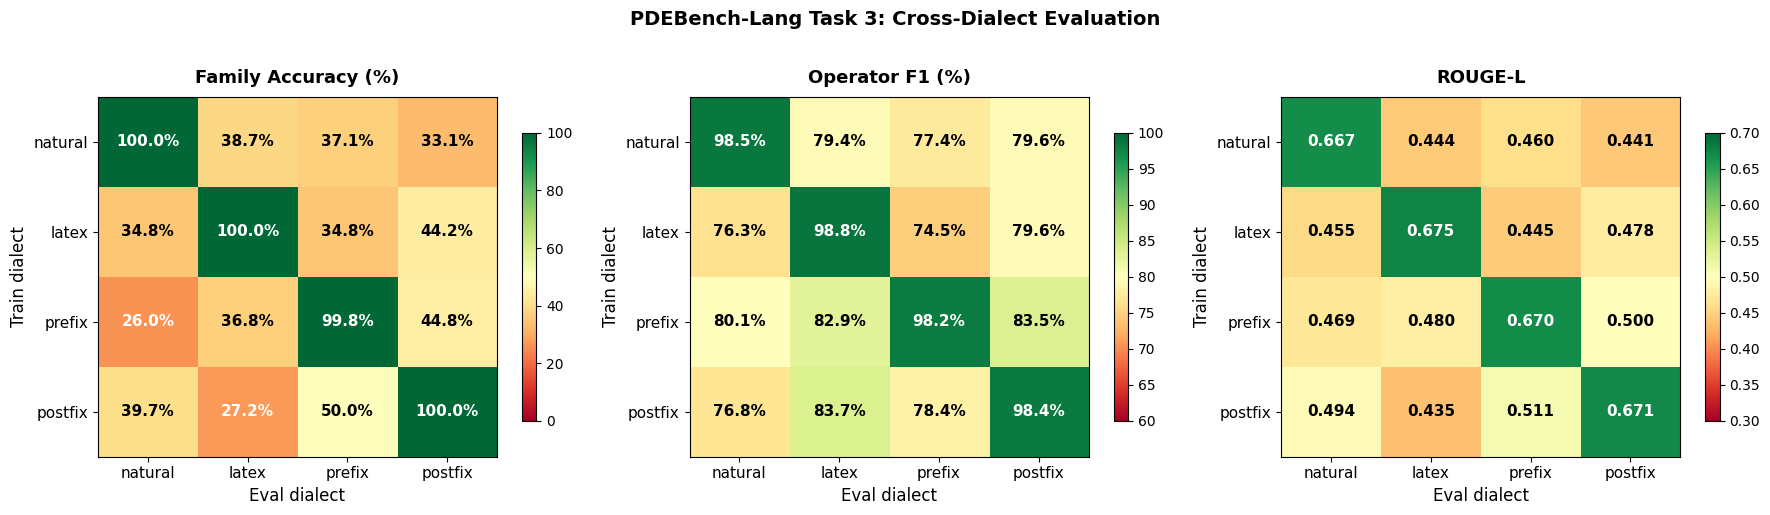

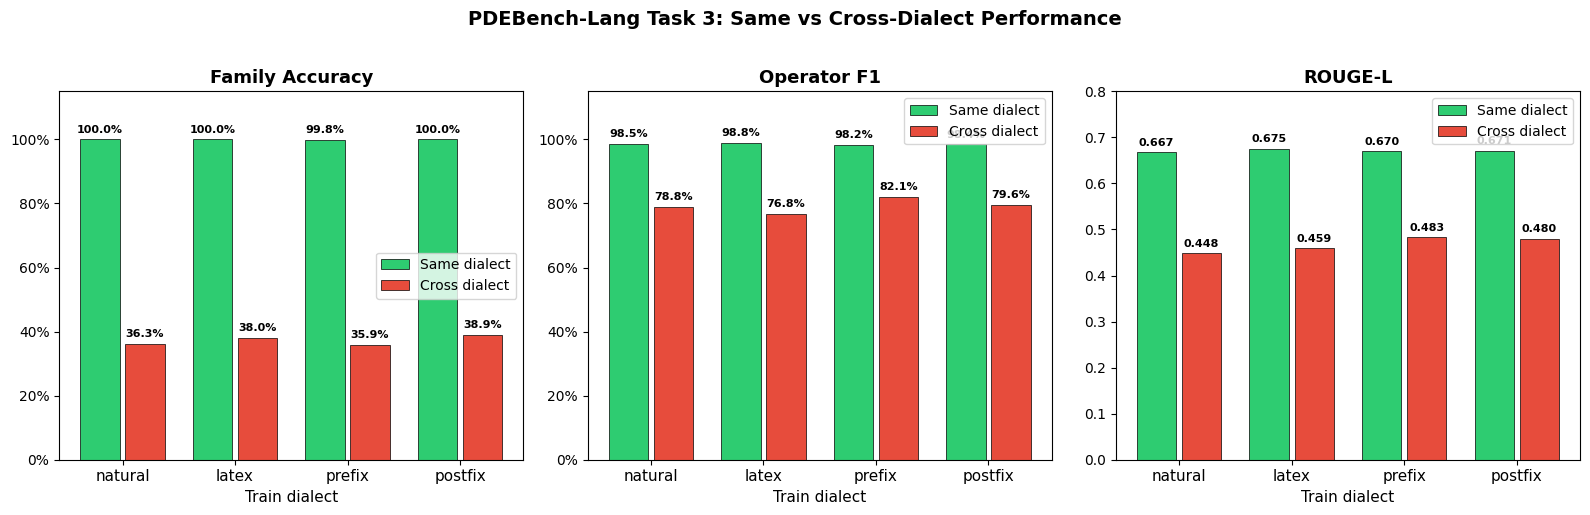

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Visualization: heatmaps and bar charts
import matplotlib.pyplot as plt
import numpy as np

dialects = ['natural', 'latex', 'prefix', 'postfix']

family_acc = [[results[td][ed]['family_accuracy']*100 for ed in dialects] for td in dialects]
op_f1      = [[results[td][ed]['operator_f1']*100     for ed in dialects] for td in dialects]
rougeL     = [[results[td][ed]['rougeL']              for ed in dialects] for td in dialects]

# ── Heatmaps ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

for ax, (mat, title, vmin, vmax, fmt) in zip(axes, [
    (family_acc, 'Family Accuracy (%)', 0,   100, '{:.1f}%'),
    (op_f1,      'Operator F1 (%)',     60,  100, '{:.1f}%'),
    (rougeL,     'ROUGE-L',             0.3, 0.7, '{:.3f}'),
]):
    m = np.array(mat)
    im = ax.imshow(m, vmin=vmin, vmax=vmax, cmap='RdYlGn', aspect='auto')
    for i in range(4):
        for j in range(4):
            val = m[i, j]
            color = 'black' if vmin + (vmax-vmin)*0.3 < val < vmin + (vmax-vmin)*0.8 else 'white'
            ax.text(j, i, fmt.format(val), ha='center', va='center', fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(dialects, fontsize=11)
    ax.set_yticklabels(dialects, fontsize=11)
    ax.set_xlabel('Eval dialect', fontsize=12)
    ax.set_ylabel('Train dialect', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('PDEBench-Lang Task 3: Cross-Dialect Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task3_heatmaps.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.patch.set_facecolor('white')

for ax, (mat, title, ylabel) in zip(axes2, [
    (family_acc, 'Family Accuracy', '%'),
    (op_f1,      'Operator F1',     '%'),
    (rougeL,     'ROUGE-L',         ''),
]):
    m = np.array(mat)
    diag    = [m[i, i] for i in range(4)]
    offdiag = [np.mean([m[i,j] for j in range(4) if j != i]) for i in range(4)]
    x = np.arange(4)
    b1 = ax.bar(x - 0.2, diag,    0.35, label='Same dialect',  color='#2ecc71', edgecolor='black', linewidth=0.5)
    b2 = ax.bar(x + 0.2, offdiag, 0.35, label='Cross dialect', color='#e74c3c', edgecolor='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(dialects, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Train dialect', fontsize=11)
    ax.legend(fontsize=10)
    if ylabel == '%':
        ax.set_ylim(0, 115)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    else:
        ax.set_ylim(0, 0.8)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        lbl = f'{h:.1f}%' if ylabel == '%' else f'{h:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, h + (1.5 if ylabel == '%' else 0.01),
                lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

fig2.suptitle('PDEBench-Lang Task 3: Same vs Cross-Dialect Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task3_bar_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Download both
from google.colab import files
files.download('task3_heatmaps.png')
files.download('task3_bar_chart.png')